# Microbe-Media Relationship Classification: CatBoost baseline

This notebook establishes a statistical baseline model for predicting microbe-cultivation media relationships using a CatBoost gradient boosting classifier. 

The pipeline performs the following key operations:
* **Data Transformation:** Loads multi-relational knowledge graph edges and transforms them into a flattened, tabular format required by tree-based ensemble algorithms.
* **Target Definition:** Enforces a single-label constraint by isolating organisms associated with exactly one cultivation medium, and filters out minority classes to ensure adequate target support.
* **Dimensionality Reduction:** Eliminates invariant features and duplicate columns to optimize the feature space prior to training.
* **Baseline Evaluation:** Trains a `CatBoostClassifier` to evaluate global classification accuracy across the network. This serves as a broad statistical benchmark to compare against the highly specific, precision-driven logic rules extracted by RDFRules.
* **Novel Inference:** Applies the trained model and feature retention masks to unlabelled organisms to predict high-confidence candidate cultivation media, exporting the results with integrated NCBI and MediaDive metadata.

## Imports

In [1]:
import datetime
import os

# data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, balanced_accuracy_score, confusion_matrix

## Parameters and configuration

In [2]:
RANDOM_SEED = 12
np.random.seed(RANDOM_SEED)

MODEL_OUTPUT_NAME = 'catboost_model_kg_microbe_baseline.cbm'
current_datetime = datetime.datetime.now().strftime("%Y-%m-%d_%H_%M")

ARTIFACTS_DIR = f'artifacts_{current_datetime}'
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

The minimum class support sets the absolute lower bound for how many occurrences of a target class (a medium) must exist in the dataset to be included. Filtering using this threshold ensures the model has enough data to learn meaningful target_object_regex_strs for a given medium, discarding sparse classes to avoid overfitting.

In [3]:
MIN_CLASS_SUPPORT = 40
MEDIUM_IDS_TO_EXCLUDE = [
    'medium:104', 'medium:1a', 'medium:215', 'medium:381', 'medium:545',
    'medium:553', 'medium:830c', 'medium:J12', 'medium:514c'
]
PROBABILITY_THRESHOLD = 0.9

## Functions

In [4]:
def remove_invariant_features(df):
    """
    Removes columns and rows where the sum indicates invariant data.
    Assumes binary (0/1) numeric data.
    - Drops columns with sum <= 1 or sum == number of rows (all 1s).
    - Drops rows with sum <= 1 or sum == number of numeric columns (all 1s).
    """
    df_cleaned = df.copy()
    
    # drop invariant columns
    unlabeled_numeric_cols_index = df_cleaned.select_dtypes(include=['number']).columns
    num_rows = df_cleaned.shape[0]
    col_sums = df_cleaned[unlabeled_numeric_cols_index].sum(axis=0)
    
    cols_to_drop = unlabeled_numeric_cols_index[(col_sums <= 1) | (col_sums == num_rows)]
    df_cleaned = df_cleaned.drop(columns=cols_to_drop)
    
    # drop invariant rows
    updated_unlabeled_numeric_cols_index = df_cleaned.select_dtypes(include=['number']).columns
    num_cols = len(updated_unlabeled_numeric_cols_index)
    row_sums = df_cleaned[updated_unlabeled_numeric_cols_index].sum(axis=1)
    
    invariant_rows_index = df_cleaned.index[(row_sums <= 1) | (row_sums == num_cols)]
    df_cleaned = df_cleaned.drop(index=invariant_rows_index)
    
    print(f"Shape before cleaning: {df.shape} -> shape after cleaning: {df_cleaned.shape}")
    return df_cleaned

## Data loading

In [5]:
kg_edges_raw_df = pd.read_csv("../data/merged-kg_edges.tsv", header=0, sep="\t")

C:\Users\katerina\AppData\Local\Temp\ipykernel_4404\1427468752.py:1: DtypeWarning: Columns (6,7,8) have mixed types. Specify dtype option on import or set low_memory=False.
  kg_edges_raw_df = pd.read_csv("../data/merged-kg_edges.tsv", header=0, sep="\t")


In [6]:
kg_nodes_raw_df = pd.read_csv("../data/merged-kg_nodes.tsv", header=0, sep="\t")

C:\Users\katerina\AppData\Local\Temp\ipykernel_4404\473766917.py:1: DtypeWarning: Columns (3,4,6,7,8,14) have mixed types. Specify dtype option on import or set low_memory=False.
  kg_nodes_raw_df = pd.read_csv("../data/merged-kg_nodes.tsv", header=0, sep="\t")


In [7]:
subject_object_pairs_df = kg_edges_raw_df[['subject','object']].drop_duplicates()

## Data preprocessing: Edge filtering

In [ ]:
# Subset the DataFrame based on the substring in subject
taxon_medium_edges_df = subject_object_pairs_df[subject_object_pairs_df['subject'].str.contains('NCBITaxon:')]
# Subset the DataFrame based on the substring in object
taxon_medium_edges_df = taxon_medium_edges_df[taxon_medium_edges_df['object'].str.contains('medium:')]
taxon_medium_edges_df.to_csv(f"{ARTIFACTS_DIR}/NCBITaxon_to_medium.tsv", sep="\t", header=True, index=False)
taxon_medium_edges_df.shape

(32513, 2)

In [9]:
taxon_go_edges_df = subject_object_pairs_df[subject_object_pairs_df['subject'].str.contains('NCBITaxon:')]
taxon_go_edges_df = taxon_go_edges_df[taxon_go_edges_df['object'].str.contains('CHEBI:')]
print(taxon_go_edges_df.shape)

(142983, 2)


In [10]:
subject_object_pairs_df_go = subject_object_pairs_df[subject_object_pairs_df['subject'].str.contains('NCBITaxon:')]
subject_object_pairs_df_go = subject_object_pairs_df_go[subject_object_pairs_df_go['object'].str.contains('GO:')]
print(subject_object_pairs_df_go.shape)

(2446, 2)


### RELEVANT predicates

50357 biolink:assesses

126997 biolink:capable_of

127784 biolink:consumes

150279 biolink:has_phenotype

26755 biolink:location_of

32513 biolink:occurs_in

3692 biolink:produces

570848 biolink:related_to

830076 biolink:subclass_of

In [11]:
# define all target prefixes
target_object_prefixes_list = [
    'carbon_substrates:', 'pathways:', 'trophic_type:', 'production:', 'CAS-RN:',
    'CHEBI:', 'EC:', 'GO:', 'cell_shape:', 'cell_length:', 'cell_width:',
    'motility:', 'sporulation:', 'pigment:', 'gram_stain:', 'gc:',
    'pH_.*:', 'temp_.*:', 'temperature:', 'salinity:', 'NaCl_.*:',
    'oxygen:', 'pathogen:', 'isolation_source:', 'ENVO:', 'UBERON:', 'PO:'
]

# create a regex target_object_regex_str
target_object_regex_str = '|'.join(target_object_prefixes_list)

# filter
taxon_subject_edges_df = subject_object_pairs_df[subject_object_pairs_df['subject'].str.contains('NCBITaxon:', na=False)]
taxon_features_combined_df = taxon_subject_edges_df[taxon_subject_edges_df['object'].str.contains(target_object_regex_str, regex=True, na=False)].copy()

print(taxon_features_combined_df.shape)

(401517, 2)


In [12]:
# define prefixes for the swapped dataframe
swapped_target_object_prefixes_list = ['PATO:', 'UBERON:', 'FOODON:', 'CHEBI:', 'ENVO:', 'PO:', 'API.*:']
target_object_regex_str_swapped = '|'.join(swapped_target_object_prefixes_list)

taxon_object_edges_df = subject_object_pairs_df[subject_object_pairs_df['object'].str.contains('NCBITaxon:', na=False)]

# Swap subject and object
taxon_object_edges_swapped_df = taxon_object_edges_df.copy()
taxon_object_edges_swapped_df['subject'], taxon_object_edges_swapped_df['object'] = taxon_object_edges_df['object'], taxon_object_edges_df['subject']

# filter using regex
taxon_features_reversed_df = taxon_object_edges_swapped_df[taxon_object_edges_swapped_df['object'].str.contains(target_object_regex_str_swapped, regex=True, na=False)].copy()

# combine with the primary dataframe
taxon_features_combined_df = pd.concat([taxon_features_combined_df, taxon_features_reversed_df], ignore_index=True)

print(taxon_features_combined_df.shape)

(404434, 2)


## Data transformation: Pivoting

In [13]:
taxon_features_combined_df['Value'] = 1

# pivot the old dataframe to form the new structure
feature_matrix_df = taxon_features_combined_df.pivot_table(index='subject', columns='object', values='Value', aggfunc='sum', fill_value=0)
feature_matrix_df = feature_matrix_df.astype(int)
print(feature_matrix_df)

object             CHEBI:100147  CHEBI:10024  CHEBI:10057  CHEBI:115156  \
subject                                                                   
NCBITaxon:100                 0            0            0             0   
NCBITaxon:100053              0            0            0             0   
NCBITaxon:1000560             0            0            0             0   
NCBITaxon:1000561             0            0            0             0   
NCBITaxon:1000562             0            0            0             0   
...                         ...          ...          ...           ...   
NCBITaxon:999702              0            0            0             0   
NCBITaxon:999891              0            0            0             0   
NCBITaxon:999892              0            0            0             0   
NCBITaxon:999894              0            0            0             0   
NCBITaxon:999931              0            0            0             0   

object             CHEBI

## Target variable definition: Single-Label Constraint

Tree-based ensemble models like CatBoost require data to be presented in a flattened, tabular format to process novel_predictions_df effectively. 
Because these algorithms lack native support for processing multi-relational graphs, we must resolve multi-label scenarios where a single organism is associated with multiple distinct cultivation media.

In this pipeline, organisms with multiple medium assignments are dropped from the dataset to ensure a strict, single-label target variable for the baseline classification.

In [14]:
# filter out 'agar' containing media IDs
agar_media_ids = kg_nodes_raw_df[kg_nodes_raw_df['name'].str.contains('agar', case=False, na=False)]['id']

# filter these IDs from taxon_medium_edges_df
taxon_features_cofiltered_taxon_medium_edges_dfmbined_df = taxon_medium_edges_df[~taxon_medium_edges_df['object'].isin(agar_media_ids)]

# filter out media containing 'agar' or the additional IDs defined in configuration
excluded_media_ids_series = kg_nodes_raw_df[kg_nodes_raw_df['id'].isin(MEDIUM_IDS_TO_EXCLUDE)]['id']

# filter these IDs from taxon_medium_edges_df
taxon_features_cofiltered_taxon_medium_edges_dfmbined_df = taxon_features_cofiltered_taxon_medium_edges_dfmbined_df[~taxon_features_cofiltered_taxon_medium_edges_dfmbined_df['object'].isin(excluded_media_ids_series)]

# group by subject and list all object (media)
taxon_to_media_list_series = taxon_features_cofiltered_taxon_medium_edges_dfmbined_df.groupby('subject')['object'].agg(list)

# filter taxons with a single medium association
taxa_with_single_medium_series = taxon_to_media_list_series[taxon_to_media_list_series.apply(len) == 1].apply(lambda x: x[0])

# create DataFrame for single media counts
single_medium_frequencies_series = taxon_features_cofiltered_taxon_medium_edges_dfmbined_df[taxon_features_cofiltered_taxon_medium_edges_dfmbined_df['object'].isin(taxa_with_single_medium_series)].groupby('object').size()

# prepare the final dataframe with taxa that have a single medium assignment
single_label_targets_df = taxa_with_single_medium_series.reset_index()
single_label_targets_df.columns = ['subject', 'MappedMedium']

# rename subject column to NCBITaxon
single_label_targets_df.rename(columns={'subject': 'NCBITaxon'}, inplace=True)
single_label_targets_df.rename(columns={'MappedMedium': 'medium'}, inplace=True)
single_label_targets_df.index = single_label_targets_df['NCBITaxon']
single_label_targets_df = single_label_targets_df.drop(columns=['NCBITaxon'])

# export to CSV inside artifacts directory
single_label_targets_df.to_csv(f"{ARTIFACTS_DIR}/taxa_media_mapping_adjusted.tsv", index=True, sep="\t")

In [15]:
print("Columns in feature_matrix_df:", feature_matrix_df.columns)
print("Columns in single_label_targets_df:", single_label_targets_df.columns)
print("Rows in feature_matrix_df:", feature_matrix_df.index)
print("Rows in single_label_targets_df:", single_label_targets_df.index)

Columns in feature_matrix_df: Index(['CHEBI:100147', 'CHEBI:10024', 'CHEBI:10057', 'CHEBI:115156',
       'CHEBI:11986', 'CHEBI:125610', 'CHEBI:12931', 'CHEBI:12936',
       'CHEBI:132106', 'CHEBI:132111',
       ...
       'trophic_type:methanotrophy', 'trophic_type:methylotrophy',
       'trophic_type:mixotrophy', 'trophic_type:oligotrophy',
       'trophic_type:organoheterotrophy', 'trophic_type:organotrophy',
       'trophic_type:photoheterotrophy', 'trophic_type:photolithotrophy',
       'trophic_type:photoorganoheterotrophy', 'trophic_type:phototrophy'],
      dtype='object', name='object', length=1219)
Columns in single_label_targets_df: Index(['medium'], dtype='object')
Rows in feature_matrix_df: Index(['NCBITaxon:100', 'NCBITaxon:100053', 'NCBITaxon:1000560',
       'NCBITaxon:1000561', 'NCBITaxon:1000562', 'NCBITaxon:1000565',
       'NCBITaxon:1000566', 'NCBITaxon:1000567', 'NCBITaxon:1000568',
       'NCBITaxon:1000569',
       ...
       'NCBITaxon:999628', 'NCBITaxon:9996

## Dataset merging and target assignment

In [16]:
feature_matrix_df = feature_matrix_df.merge(single_label_targets_df, left_index=True, right_index=True, how='left')
full_feature_matrix_df = feature_matrix_df.copy()

feature_matrix_df = feature_matrix_df[feature_matrix_df['medium'].notna()]

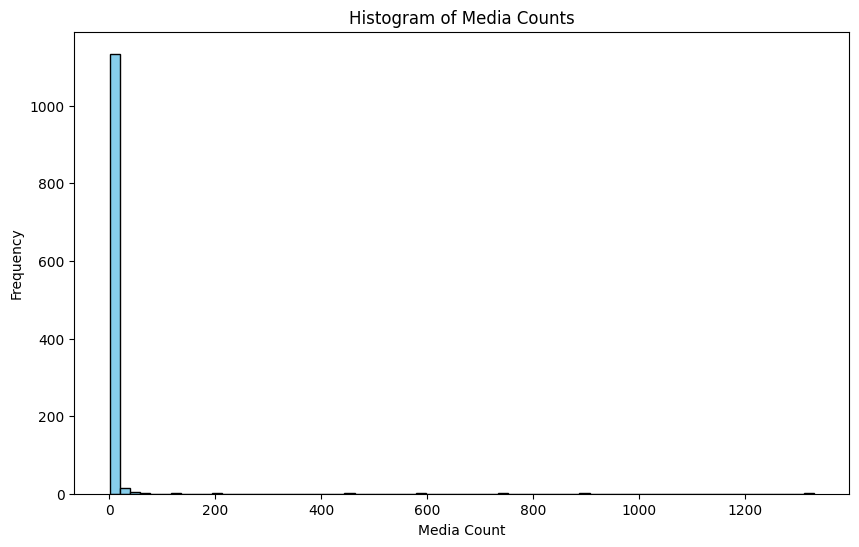

In [18]:
# assuming taxon_features_cofiltered_taxon_medium_edges_dfmbined_df['MediaCount'] exists and is populated with the occurrence counts of each medium
plt.figure(figsize=(10, 6))  # Optional: Adjusts the size of the plot
plt.hist(feature_matrix_df['medium'].value_counts(), bins='auto', color='skyblue', edgecolor='black')
plt.title('Histogram of Media Counts')
plt.xlabel('Media Count')
plt.ylabel('Frequency')

plt.show()

In [19]:
feature_matrix_df = feature_matrix_df[feature_matrix_df['medium'].notna()]

In [20]:
feature_matrix_index_series = pd.Series(feature_matrix_df.index.values)

# save this series to TSV file inside artifacts directory
feature_matrix_index_series.to_csv(f"{ARTIFACTS_DIR}/feature_matrix_df__taxa_to_media__NCBITaxon_index.tsv", sep='\t', index=False, header=False)

In [21]:

# Extracting unique values from the 'medium' column
unique_mediums = feature_matrix_df['medium'].unique()
print(len(unique_mediums))

1164


## Feature selection

### Invariant feature removal
This step isolates the numeric features and fills missing values. It then removes columns and rows that lack variance (e.g., all zeros or all ones) to optimize the dataset dimensionality before training.

In [22]:
clean_feature_matrix_df = feature_matrix_df.copy()

In [23]:
# select only the numerical columns (excluding 'medium')
numerical_features_df = clean_feature_matrix_df.select_dtypes(include=np.number)

# add the 'medium' column back for grouping
if 'medium' not in numerical_features_df.columns:
    numerical_features_df['medium'] = clean_feature_matrix_df['medium']

for col in numerical_features_df.columns[:-1]:  # Exclude 'medium' from filling NaNs
    numerical_features_df[col].fillna(0, inplace=True)

# remove invariant features
clean_feature_matrix_df = remove_invariant_features(clean_feature_matrix_df)

C:\Users\katerina\AppData\Local\Temp\ipykernel_4404\193274234.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  numerical_features_df[col].fillna(0, inplace=True)


Shape before cleaning: (7644, 1220) -> shape after cleaning: (6731, 713)


In [24]:
# Print detailed statistics for 'medium:65' to understand the data spread
print(numerical_features_df[numerical_features_df['medium'] == 'medium:65'].describe())

# Additionally, check for any duplicates or unexpected entries
print("Check for duplicates in pre-melt data for 'medium:65':", numerical_features_df[numerical_features_df['medium'] == 'medium:65'].duplicated().sum())


       CHEBI:100147  CHEBI:10024  CHEBI:10057  CHEBI:115156  CHEBI:11986  \
count    744.000000        744.0        744.0         744.0        744.0   
mean       0.004032          0.0          0.0           0.0          0.0   
std        0.063415          0.0          0.0           0.0          0.0   
min        0.000000          0.0          0.0           0.0          0.0   
25%        0.000000          0.0          0.0           0.0          0.0   
50%        0.000000          0.0          0.0           0.0          0.0   
75%        0.000000          0.0          0.0           0.0          0.0   
max        1.000000          0.0          0.0           0.0          0.0   

       CHEBI:125610  CHEBI:12931  CHEBI:12936  CHEBI:132106  CHEBI:132111  \
count    744.000000        744.0   744.000000         744.0         744.0   
mean       0.001344          0.0     0.032258           0.0           0.0   
std        0.036662          0.0     0.176804           0.0           0.0   
min    

### Target variable: minority class support filtering

In [25]:
# filter out minority classes using configuration threshold
clean_feature_matrix_df = clean_feature_matrix_df.groupby('medium').filter(lambda x : len(x) >= MIN_CLASS_SUPPORT)
print(clean_feature_matrix_df)

                   CHEBI:100147  CHEBI:10057  CHEBI:115156  CHEBI:12931  \
subject                                                                   
NCBITaxon:1001240             0            0             0            0   
NCBITaxon:1003110             0            0             0            0   
NCBITaxon:1004279             0            0             0            0   
NCBITaxon:1004304             0            0             0            0   
NCBITaxon:1004316             0            0             0            0   
...                         ...          ...           ...          ...   
NCBITaxon:999549              0            0             0            0   
NCBITaxon:999550              0            0             0            0   
NCBITaxon:999552              0            0             0            0   
NCBITaxon:999611              0            0             0            0   
NCBITaxon:999931              0            0             0            0   

                   CHEBI

In [26]:
clean_feature_matrix_df = remove_invariant_features(clean_feature_matrix_df)

Shape before cleaning: (4103, 713) -> shape after cleaning: (4103, 578)


### Duplicate column removal

In [27]:
target_object_regex_strs = {}
duplicate_columns_list = []
feature_retention_map_dict = {}

for col in clean_feature_matrix_df.columns:
    target_object_regex_str = tuple(clean_feature_matrix_df[col])
    if target_object_regex_str not in target_object_regex_strs:
        target_object_regex_strs[target_object_regex_str] = col
        feature_retention_map_dict[col] = []  # initialize the list of dropped columns for this target_object_regex_str
    else:
        # add the current column to the drop list and map it to the retained column
        duplicate_columns_list.append(col)
        feature_retention_map_dict[target_object_regex_strs[target_object_regex_str]].append(col)

# drop duplicate columns
clean_feature_matrix_df = clean_feature_matrix_df.drop(columns=duplicate_columns_list)

feature_retention_df = pd.DataFrame(
    [(retained, ','.join(duplicates)) for retained, duplicates in feature_retention_map_dict.items() if duplicates],
    columns=['Retained Column', 'Deleted Columns']
)

# write to CSV file
feature_retention_df.to_csv(f"{ARTIFACTS_DIR}/kg_microbe_train_tax_to_media_retention_map.csv", index=False)
print(feature_retention_df)

                           Retained Column  \
0                             CHEBI:133748   
1                              CHEBI:16632   
2                              CHEBI:30796   
3                              CHEBI:32892   
4                               GO:0015946   
5  pathways:aerobic_anoxygenic_phototrophy   
6            pathways:aerobic_heterotrophy   

                                     Deleted Columns  
0                                        CHEBI:50744  
1                                        CHEBI:29749  
2                                        CHEBI:30797  
3                            CHEBI:41808,CHEBI:45296  
4                             pathways:methylotrophy  
5                         pathways:photoheterotrophy  
6  pathways:nitrate_reduction_to_ammonia,pathways...  


In [28]:
file_path = f"{ARTIFACTS_DIR}/taxa_to_media_clean_feature_matrix_df.tsv.gz"
clean_feature_matrix_df.to_csv(file_path, sep='\t', index=True, header=True, compression='gzip')

## Data split (train/validation/test)

In [29]:
# splitting the data into features and target labels
X = clean_feature_matrix_df.drop('medium', axis=1)
y = clean_feature_matrix_df['medium']

In [30]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=RANDOM_SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.33, stratify=y_temp, random_state=RANDOM_SEED)

catboost_train_pool = Pool(data=X_train, label=y_train, cat_features=[])
catboost_val_pool = Pool(data=X_val, label=y_val, cat_features=[])
catboost_test_pool = Pool(data=X_test, label=y_test, cat_features=[])

In [31]:
# save the train, val, and test files to the artifacts directory
X_train.to_csv(f"{ARTIFACTS_DIR}/train.tsv", sep='\t', index=True)
y_train.to_csv(f"{ARTIFACTS_DIR}/y_train.tsv", sep='\t', index=True)

X_val.to_csv(f"{ARTIFACTS_DIR}/val.tsv", sep='\t', index=True)
y_val.to_csv(f"{ARTIFACTS_DIR}/y_val.tsv", sep='\t', index=True)

X_test.to_csv(f"{ARTIFACTS_DIR}/test.tsv", sep='\t', index=True)
y_test.to_csv(f"{ARTIFACTS_DIR}/y_test.tsv", sep='\t', index=True)

## Model training: CatBoost classifier

In [32]:
%%time
catboost_model = CatBoostClassifier(random_seed=RANDOM_SEED,
                           iterations=10000, 
                           loss_function="MultiClass",
                           learning_rate=0.05,#0.001
                           depth=4,
                           l2_leaf_reg=4,
                           bagging_temperature=1,
                           random_strength=6,
                           verbose=100)
catboost_model.fit(catboost_train_pool, 
          eval_set=catboost_val_pool,
          early_stopping_rounds=50 
         )

0:	learn: 2.2538411	test: 2.2546133	best: 2.2546133 (0)	total: 152ms	remaining: 25m 20s
100:	learn: 1.3943114	test: 1.4355567	best: 1.4355567 (100)	total: 1.1s	remaining: 1m 47s
200:	learn: 1.1200036	test: 1.1903908	best: 1.1903908 (200)	total: 1.99s	remaining: 1m 36s
300:	learn: 0.9245099	test: 1.0250805	best: 1.0250805 (300)	total: 2.85s	remaining: 1m 31s
400:	learn: 0.8397343	test: 0.9585568	best: 0.9585568 (400)	total: 3.81s	remaining: 1m 31s
500:	learn: 0.7931799	test: 0.9263731	best: 0.9263731 (500)	total: 4.65s	remaining: 1m 28s
600:	learn: 0.7582149	test: 0.9047266	best: 0.9047266 (600)	total: 5.52s	remaining: 1m 26s
700:	learn: 0.7309578	test: 0.8893182	best: 0.8893093 (698)	total: 6.41s	remaining: 1m 25s
800:	learn: 0.7080985	test: 0.8768432	best: 0.8767972 (798)	total: 7.33s	remaining: 1m 24s
900:	learn: 0.6881930	test: 0.8665009	best: 0.8665009 (900)	total: 8.17s	remaining: 1m 22s
1000:	learn: 0.6697234	test: 0.8569815	best: 0.8569815 (1000)	total: 9.13s	remaining: 1m 22s
1

CatBoostClassifier(bagging_temperature=1, depth=4, iterations=10000, l2_leaf_reg=4, learning_rate=0.05, loss_function='MultiClass', random_seed=12, random_strength=6, verbose=100)

## Model evaluation

In [33]:
# predict on test data
y_pred = catboost_model.predict(catboost_test_pool)
y_pred_proba = catboost_model.predict_proba(catboost_test_pool)[:,1]  # novel_probabilities_array for the positive class

# metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))  # Adding balanced accuracy
print("\nClassification Report:\n", classification_report(y_test, y_pred))
#print("AUC-ROC:", roc_auc_score(y_test, y_pred_proba))

Accuracy: 0.7223587223587223
Balanced Accuracy: 0.6597532118436074

Classification Report:
               precision    recall  f1-score   support

medium:1076b       1.00      0.83      0.91         6
   medium:11       0.86      0.67      0.75        18
  medium:514       0.75      0.91      0.82       118
  medium:645       0.62      0.45      0.53        11
   medium:65       0.68      0.85      0.76        66
  medium:693       0.78      0.69      0.73        42
  medium:830       0.73      0.60      0.66        81
   medium:92       0.59      0.44      0.51        52
   medium:98       0.67      0.40      0.50         5
  medium:J14       0.60      0.75      0.67         8

    accuracy                           0.72       407
   macro avg       0.73      0.66      0.68       407
weighted avg       0.72      0.72      0.71       407



The global test accuracy for this tabular gradient boosting baseline model is ~72.2%. 
This aligns with the performance benchmark evaluated in the associated manuscript (Table 5), 
which compares the broad statistical classification capabilities of the gradient boosting model 
against the highly specific, precision-driven logic rules extracted by RDFRules.

In [34]:
# save the model into the centralized artifacts directory
catboost_model_path = os.path.join(ARTIFACTS_DIR, MODEL_OUTPUT_NAME)
catboost_model.save_model(catboost_model_path)

print(f"Model successfully saved to {catboost_model_path}")

Model successfully saved to artifacts_2026-09-02_13_52\catboost_model_kg_microbe_baseline.cbm


In [35]:
# generate classification report
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Note: precision and recall are not defined for the 'accuracy' row, so they are excluded it from the filter
report_filtered_df = report_df[(report_df['precision'] > 0.9) & (report_df['recall'] > 0.9)]
print(report_filtered_df)

Empty DataFrame
Columns: [precision, recall, f1-score, support]
Index: []


In [36]:
report_df[(report_df['precision'] > 0.8) & (report_df['recall'] > 0.5)]

,precision,recall,f1-score,support
medium:1076b,1.000000,0.833333,0.909091,6.0
medium:11,0.857143,0.666667,0.750000,18.0


### High-confidence classification report
Filters the classification report to highlight only the media classes where the model achieved both precision > 0.8 and recall > 0.5.

In [37]:
report_filtered_80_df = report_df[(report_df['precision'] > 0.8) & (report_df['recall'] > 0.5)]
print(report_filtered_80_df)

              precision    recall  f1-score  support
medium:1076b   1.000000  0.833333  0.909091      6.0
medium:11      0.857143  0.666667  0.750000     18.0


In [39]:
# predict on train data
y_pred_train = catboost_model.predict(catboost_train_pool)
y_pred_proba_train = catboost_model.predict_proba(catboost_train_pool)[:,1]  # novel_probabilities_array for the positive class

# metrics                                                                                                                        
print("Accuracy:", accuracy_score(y_train, y_pred_train))
print("Balanced Accuracy:", balanced_accuracy_score(y_train, y_pred_train))  # adding balanced accuracy
print("\nClassification Report:\n", classification_report(y_train, y_pred_train))
#print("AUC-ROC:", roc_auc_score(y_test, y_pred_proba))

Accuracy: 0.8582869080779945
Balanced Accuracy: 0.8501728966045399

Classification Report:
               precision    recall  f1-score   support

medium:1076b       0.77      0.84      0.80        44
   medium:11       0.97      0.94      0.96       126
  medium:514       0.81      0.95      0.88       831
  medium:645       0.86      0.85      0.86        80
   medium:65       0.80      0.91      0.85       463
  medium:693       0.93      0.86      0.90       297
  medium:830       0.91      0.76      0.83       573
   medium:92       0.89      0.71      0.79       367
   medium:98       0.96      0.79      0.87        34
  medium:J14       0.94      0.88      0.91        57

    accuracy                           0.86      2872
   macro avg       0.89      0.85      0.86      2872
weighted avg       0.87      0.86      0.86      2872



## Plots

### Feature Importance
Extracts and visualizes the top contributing features utilized by the model for classification.

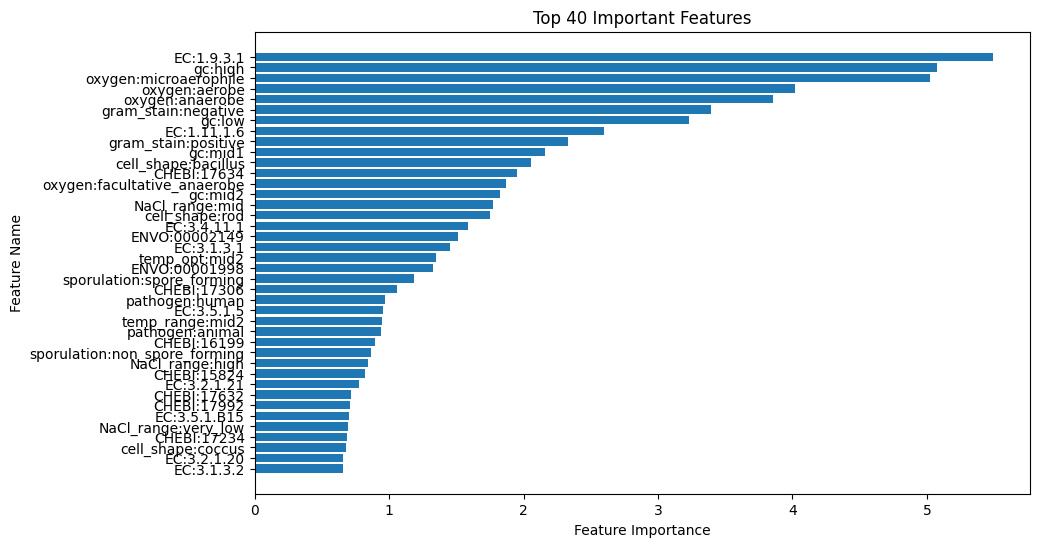

In [40]:
feature_importances = catboost_model.get_feature_importance()
feature_names = X_test.columns.values

# create a list of (feature_name, importance) tuples
feature_importance_tuples = [(name, importance) for name, importance in zip(feature_names, feature_importances)]

topn = 40
top_100_features = sorted(feature_importance_tuples, key=lambda x: x[1], reverse=True)[:topn]

# separate the feature names and their importances
top_features, top_importances = zip(*top_100_features)

# bar plot
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_importances)), top_importances, align='center')
plt.yticks(range(len(top_importances)), top_features)
plt.gca().invert_yaxis()  # Invert y-axis to have the most important feature on top
plt.xlabel('Feature Importance')
plt.ylabel('Feature Name')
plt.title('Top '+str(topn)+' Important Features')

figure_name = "top_"+str(topn)+"_features_catboost__traingreat39_filtervar0.015_iterate"
plt.savefig(f"{ARTIFACTS_DIR}/{figure_name}.pdf", format='pdf', bbox_inches='tight')
plt.savefig(f"{ARTIFACTS_DIR}/{figure_name}.png", format='png', bbox_inches='tight')

plt.show()

### Confusion matrix
Evaluates class-level prediction accuracy and misclassification target_object_regex_strs on the test set.

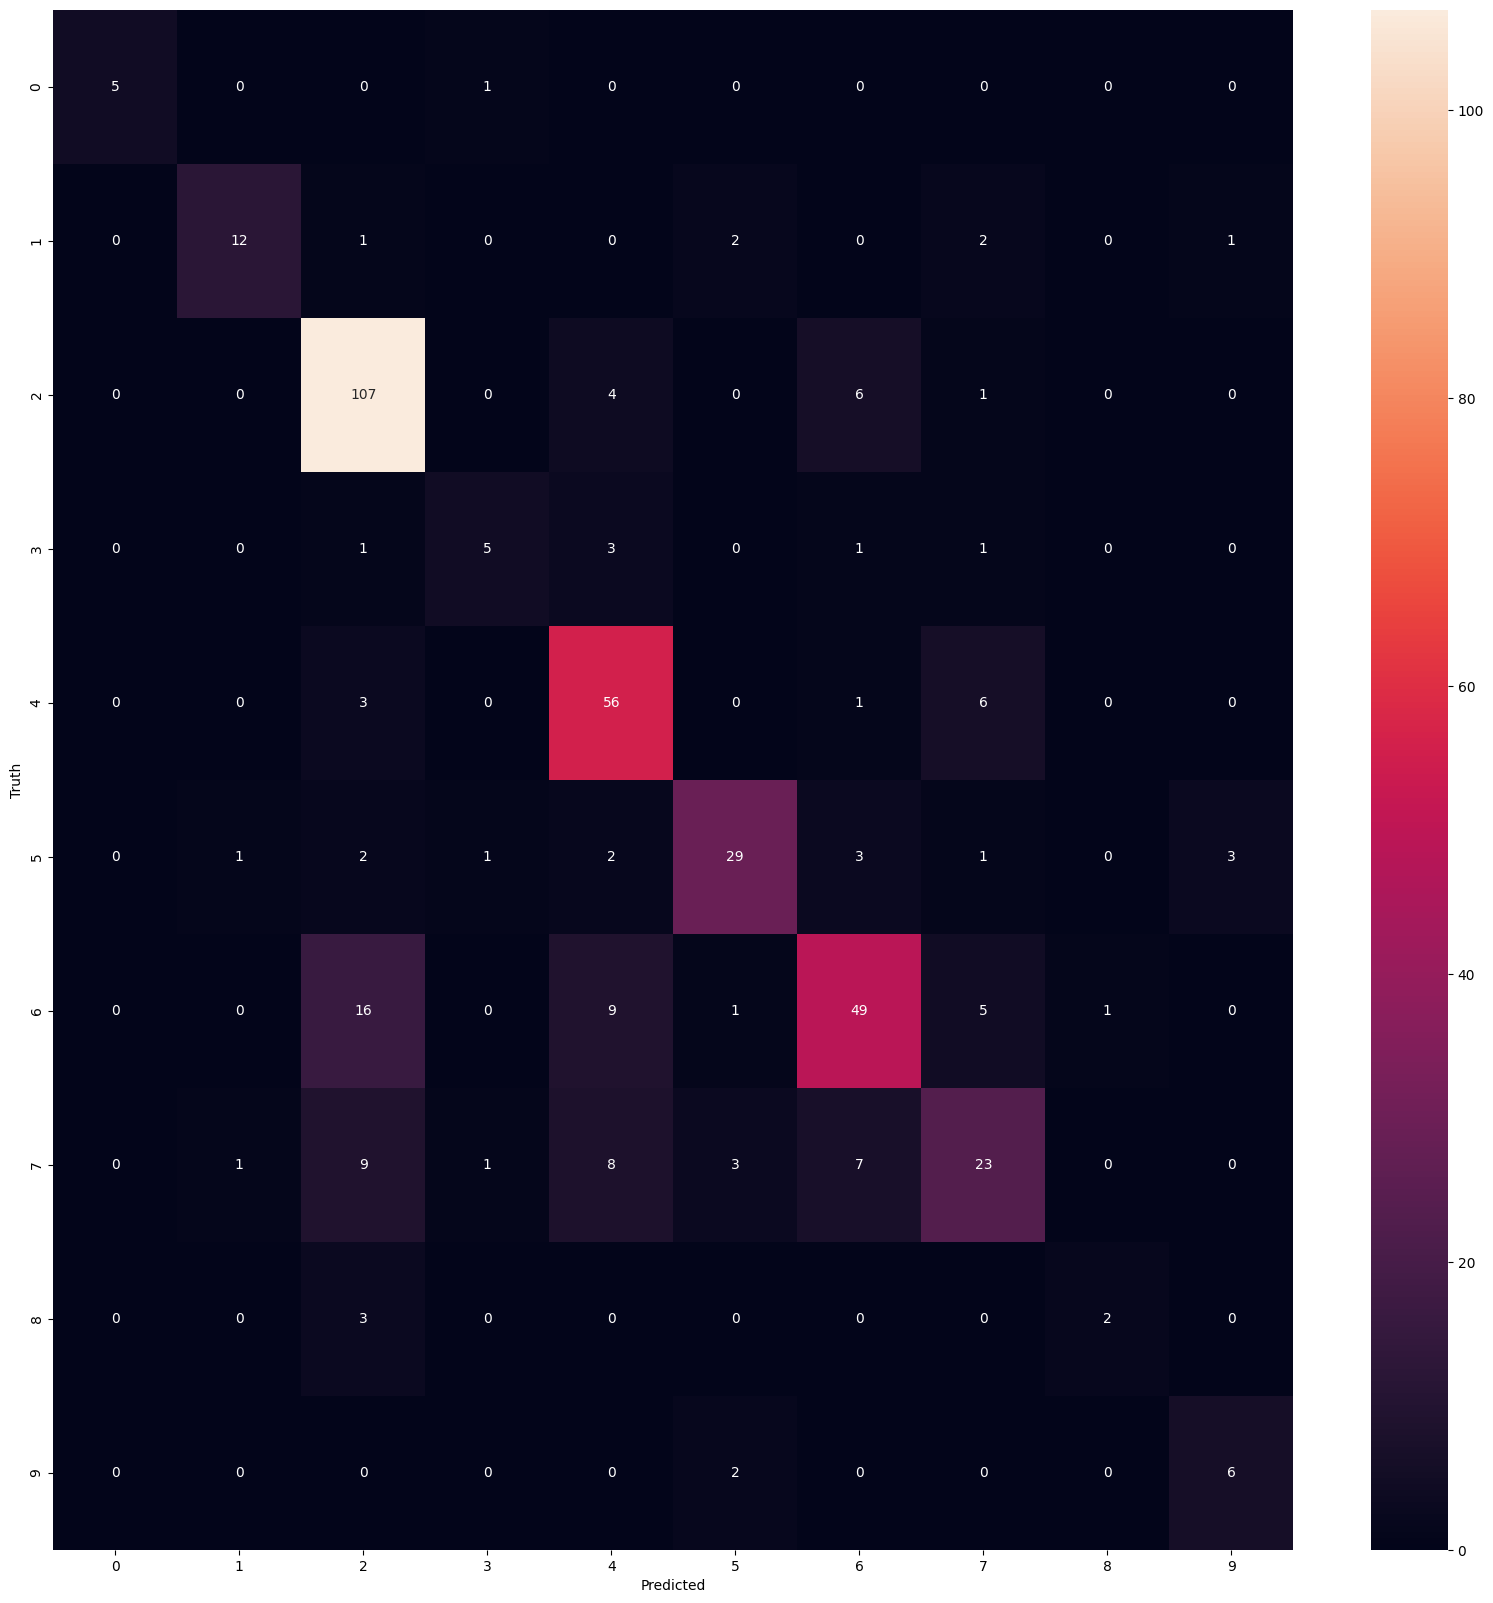

In [41]:
# True labels are assumed to be in y_test
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(20,20))
sns.heatmap(cm, annot=True, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.savefig(f'{ARTIFACTS_DIR}/confusion_'+ current_datetime +'__GO__traingreat39_filtervar0.015_iterate.pdf', format='pdf')
plt.show()

### Novel predictions on unlabeled data

This section isolates organisms lacking assigned cultivation media in the source graph. It applies the exact feature retention mask established during training to ensure dimensional consistency before inference.

In [42]:
unlabeled_feature_matrix_df = full_feature_matrix_df[full_feature_matrix_df['medium'].isna()]
print(unlabeled_feature_matrix_df.shape)

(32002, 1220)


## Novel predictions on unlabeled data

### Unlabeled data preparation
This section isolates organisms lacking assigned cultivation media in the source graph. It applies the exact feature retention mask established during training to ensure dimensional consistency before inference.

In [43]:
training_columns_index = clean_feature_matrix_df.columns

# filter columns in unlabeled_feature_matrix_df
unlabeled_filtered_matrix_df = unlabeled_feature_matrix_df[training_columns_index]

# select only numeric columns for the operation
unlabeled_numeric_cols_index = unlabeled_filtered_matrix_df.select_dtypes(include=['number']).columns

# remove rows with sum <= 1, ensuring to only sum over the updated numeric columns
unlabeled_numeric_cols_index = unlabeled_filtered_matrix_df.select_dtypes(include=['number']).columns
current_dimensions_tuple = unlabeled_filtered_matrix_df.shape
print(current_dimensions_tuple)
row_sums_series = unlabeled_filtered_matrix_df[unlabeled_numeric_cols_index].sum(axis=1)
invariant_rows_index = unlabeled_filtered_matrix_df.index[row_sums_series <= 1]
unlabeled_filtered_matrix_df = unlabeled_filtered_matrix_df.drop(index=invariant_rows_index)

# remove rows which are all 1
unlabeled_numeric_cols_index = unlabeled_filtered_matrix_df.select_dtypes(include=['number']).columns
current_dimensions_tuple = unlabeled_filtered_matrix_df.shape
print(current_dimensions_tuple)

row_sums_series = unlabeled_filtered_matrix_df[unlabeled_numeric_cols_index].sum(axis=1)
invariant_rows_index = unlabeled_filtered_matrix_df.index[row_sums_series == current_dimensions_tuple[0]]
unlabeled_filtered_matrix_df = unlabeled_filtered_matrix_df.drop(index=invariant_rows_index)
print(current_dimensions_tuple)

(32002, 569)
(22906, 569)
(22906, 569)


### Inference and metadata integration
Executes model inference on the unlabeled data. The raw class novel_probabilities_array are extracted, mapped to the highest scoring medium, and joined with external metadata (NCBI and MediaDive URLs) for downstream biological validation.

In [44]:
X2 = unlabeled_filtered_matrix_df.drop('medium', axis=1)
y2 = unlabeled_filtered_matrix_df['medium']

# predict on new data
novel_predicted_classes_array = catboost_model.predict(X2)
novel_probabilities_array = catboost_model.predict_proba(X2)

max_prob_indices_array = np.argmax(novel_probabilities_array, axis=1)

# find the max values in each row
max_prob_values_array = np.max(novel_probabilities_array, axis=1)

# combine row IDs, max values, and column IDs
prediction_results_array = np.column_stack((np.arange(novel_probabilities_array.shape[0]), max_prob_values_array, max_prob_indices_array))

novel_predictions_df = pd.DataFrame(prediction_results_array, columns=['row_id', 'prob_max', 'media_id'])

novel_predictions_df['row_id'] = novel_predictions_df['row_id'].apply(lambda x: X2.index.values[int(x)])
novel_predictions_df['media_id'] = novel_predictions_df['media_id'].apply(lambda x: novel_predicted_classes_array[int(x)][0])

novel_predictions_df = novel_predictions_df.sort_values(by='prob_max', ascending=False)

novel_predictions_df = novel_predictions_df.merge(kg_nodes_raw_df[['id', 'name']], left_on='row_id', right_on='id', how='left')
novel_predictions_df.rename(columns={'name': 'row_id_label'}, inplace=True)
novel_predictions_df.drop('id', axis=1, inplace=True)

# merge to get media_id_label
novel_predictions_df = novel_predictions_df.merge(kg_nodes_raw_df[['id', 'name']], left_on='media_id', right_on='id', how='left')
novel_predictions_df.rename(columns={'name': 'media_id_label'}, inplace=True)
novel_predictions_df.drop('id', axis=1, inplace=True)

In [45]:
def extract_ncbi_id(row_id):
    return row_id.split(':')[-1]

# function to extract ID after colon for MediaDive link
def extract_media_id(media_id):
    return media_id.split(':')[-1]

In [48]:
# create the ncbi_link column
novel_predictions_df['ncbi_link'] = 'https://www.ncbi.nlm.nih.gov/Taxonomy/Browser/wwwtax.cgi?id=' + novel_predictions_df['row_id'].apply(extract_ncbi_id)

# create the media_link column
novel_predictions_df['media_link'] = 'https://mediadive.dsmz.de/medium/' + novel_predictions_df['media_id'].apply(extract_media_id)

new_column_order = ['row_id', 'media_id', 'prob_max', 'row_id_label', 'media_id_label', 'ncbi_link', 'media_link']

novel_predictions_df = novel_predictions_df[new_column_order]
print(novel_predictions_df.head())

             row_id    media_id  prob_max  \
0    NCBITaxon:1894  medium:514  0.999971   
1   NCBITaxon:33900  medium:514  0.999918   
2  NCBITaxon:278992  medium:514  0.999898   
3  NCBITaxon:566461  medium:514  0.999854   
4     NCBITaxon:727  medium:J14  0.999846   

                           row_id_label  \
0            Kitasatospora aureofaciens   
1                  Streptomyces murinus   
2   Streptomyces ambofaciens ATCC 23877   
3  Streptomyces viridosporus ATCC 14672   
4                Haemophilus influenzae   

                                      media_id_label  \
0  BACTO MARINE BROTH (DIFCO 2216) (DSMZ Medium 514)   
1  BACTO MARINE BROTH (DIFCO 2216) (DSMZ Medium 514)   
2  BACTO MARINE BROTH (DIFCO 2216) (DSMZ Medium 514)   
3  BACTO MARINE BROTH (DIFCO 2216) (DSMZ Medium 514)   
4                                          EG MEDIUM   

                                           ncbi_link  \
0  https://www.ncbi.nlm.nih.gov/Taxonomy/Browser/...   
1  https://www.ncbi.n

In [49]:
novel_predictions_df[novel_predictions_df['prob_max'] > 0.99]

,row_id,media_id,prob_max,row_id_label,media_id_label,ncbi_link,media_link
0,NCBITaxon:1894,medium:514,0.999971,Kitasatospora aureofaciens,BACTO MARINE BROTH (DIFCO 2216) (DSMZ Medium 514),https://www.ncbi.nlm.nih.gov/Taxonomy/Browser/...,https://mediadive.dsmz.de/medium/514
1,NCBITaxon:33900,medium:514,0.999918,Streptomyces murinus,BACTO MARINE BROTH (DIFCO 2216) (DSMZ Medium 514),https://www.ncbi.nlm.nih.gov/Taxonomy/Browser/...,https://mediadive.dsmz.de/medium/514
2,NCBITaxon:278992,medium:514,0.999898,Streptomyces ambofaciens ATCC 23877,BACTO MARINE BROTH (DIFCO 2216) (DSMZ Medium 514),https://www.ncbi.nlm.nih.gov/Taxonomy/Browser/...,https://mediadive.dsmz.de/medium/514
3,NCBITaxon:566461,medium:514,0.999854,Streptomyces viridosporus ATCC 14672,BACTO MARINE BROTH (DIFCO 2216) (DSMZ Medium 514),https://www.ncbi.nlm.nih.gov/Taxonomy/Browser/...,https://mediadive.dsmz.de/medium/514
4,NCBITaxon:727,medium:J14,0.999846,Haemophilus influenzae,EG MEDIUM,https://www.ncbi.nlm.nih.gov/Taxonomy/Browser/...,https://mediadive.dsmz.de/medium/J14
...,...,...,...,...,...,...,...
372,NCBITaxon:1206725,medium:514,0.990119,Nocardia brevicatena NBRC 12119,BACTO MARINE BROTH (DIFCO 2216) (DSMZ Medium 514),https://www.ncbi.nlm.nih.gov/Taxonomy/Browser/...,https://mediadive.dsmz.de/medium/514
373,NCBITaxon:47762,medium:514,0.990103,Streptomyces ramulosus,BACTO MARINE BROTH (DIFCO 2216) (DSMZ Medium 514),https://www.ncbi.nlm.nih.gov/Taxonomy/Browser/...,https://mediadive.dsmz.de/medium/514
374,NCBITaxon:1130726,medium:830,0.990081,Defluviimonas aestuarii,R2A MEDIUM (DSMZ Medium 830),https://www.ncbi.nlm.nih.gov/Taxonomy/Browser/...,https://mediadive.dsmz.de/medium/830
375,NCBITaxon:1224742,medium:830,0.990009,Vibrio campbellii CAIM 519 = NBRC 15631 = ATCC...,R2A MEDIUM (DSMZ Medium 830),https://www.ncbi.nlm.nih.gov/Taxonomy/Browser/...,https://mediadive.dsmz.de/medium/830


### Exporting high-confidence candidates
Filters the novel predictions exceeding the defined probability threshold and exports the subset to the artifacts directory.

In [50]:
high_confidence_predictions_df = novel_predictions_df[novel_predictions_df['prob_max'] > PROBABILITY_THRESHOLD]
high_confidence_predictions_df.to_csv(f"{ARTIFACTS_DIR}/high_confidence_predictions_df_{PROBABILITY_THRESHOLD}.tsv", sep='\t', index=False)

print(f"Total high-confidence predictions (> {PROBABILITY_THRESHOLD}): {high_confidence_predictions_df.shape[0]}")

Total high-confidence predictions (> 0.9): 2266


In [51]:
novel_predictions_df[novel_predictions_df['media_id'] == 'medium:830'][1:30]['row_id_label'
]

39                              Vibrio breoganii
49                            Zobellia russellii
61                       Psychrobacter maritimus
67                         Fulvivirga kasyanovii
72                      Pseudidiomarina maritima
81                     Aliidiomarina taiwanensis
87                       Salinimicrobium marinum
93                   Pseudorhodobacter aquimaris
94                       Pseudahrensia aquimaris
95                         Bermanella marisrubri
97                       Halobacillus dabanensis
107                         Namhaeicola litoreus
110                  Pseudidiomarina tainanensis
111                       Pseudidiomarina marina
114                       Pseudidiomarina indica
120                            Maritalea mobilis
121                          Microbulbifer celer
122                       Bizionia hallyeonensis
123                       Qipengyuania aquimaris
125                               Stappia indica
126                 

In [53]:
novel_media_counts_series = novel_predictions_df['media_id_label'].value_counts()
print(novel_media_counts_series)

media_id_label
R2A MEDIUM (DSMZ Medium 830)                         8727
BACTO MARINE BROTH (DIFCO 2216) (DSMZ Medium 514)    7276
MIDDLEBROOK MEDIUM (DSMZ Medium 645)                 5068
EG MEDIUM                                            1547
COLUMBIA BLOOD MEDIUM (DSMZ Medium 693)               288
Name: count, dtype: int64


In [54]:
novel_predictions_df.to_csv(f'{ARTIFACTS_DIR}/pred' + current_datetime + '__traingreat39_filtervar0.015_iterate.tsv', sep='\t', index=False)

In [55]:
novel_media_counts_series = novel_predictions_df['media_id'].value_counts()
print(novel_media_counts_series)

media_id
medium:830    8727
medium:514    7276
medium:645    5068
medium:J14    1547
medium:693     288
Name: count, dtype: int64


In [57]:
high_conf_media_counts_series = novel_predictions_df[novel_predictions_df['prob_max'] > 0.9]['media_id'].value_counts()
print(high_conf_media_counts_series)

media_id
medium:830    865
medium:514    733
medium:645    473
medium:J14    186
medium:693      9
Name: count, dtype: int64


In [59]:
train_media_counts_series = y.value_counts()
print(train_media_counts_series)

medium
medium:514      1188
medium:830       818
medium:65        662
medium:92        524
medium:693       424
medium:11        180
medium:645       114
medium:J14        81
medium:1076b      63
medium:98         49
Name: count, dtype: int64


### Distribution analysis: predictions vs. training
Compares the frequency distribution of the predicted media assignments against the original training distribution to check for systemic classification bias or over-prediction of majority classes.

In [60]:
pred_distribution_df = high_conf_media_counts_series.reset_index()
train_distribution_df = train_media_counts_series.reset_index()

pred_distribution_df.columns = ['media_id', 'pred_count']
train_distribution_df.columns = ['media_id', 'train_count']

# merge on media_id
distribution_comparison_df = pd.merge(pred_distribution_df, train_distribution_df, on='media_id', how='inner')

# calculate the ratio of pred_count to train_count
distribution_comparison_df['ratio'] = distribution_comparison_df['pred_count']/distribution_comparison_df['train_count']

# Display the result
print(distribution_comparison_df)

     media_id  pred_count  train_count     ratio
0  medium:830         865          818  1.057457
1  medium:514         733         1188  0.617003
2  medium:645         473          114  4.149123
3  medium:J14         186           81  2.296296
4  medium:693           9          424  0.021226
